In [2]:
from scipy.interpolate import RBFInterpolator
import settings
import numpy as np
import itertools
import os

In [3]:
def generate_w_batch_test(args, step_size):
    mesh_array = []
    step_size = step_size
    for i in range(args.reward_size):
        mesh_array.append(np.arange(0,1+step_size, step_size))
        
    w_batch_test = np.array(list(itertools.product(*mesh_array)))
    w_batch_test = w_batch_test[w_batch_test.sum(axis=1) == 1,:]
    w_batch_test = np.unique(w_batch_test,axis =0)
    
    return w_batch_test

In [4]:
# Initialize Interpolator
args = settings.HYPERPARAMS["HPC_MO_TD3_HER"]
args.reward_size = 2

# 16 points from (0,1) --> (1,0)
alphas = np.linspace(0.0, 1.0, 16)                      
w_batch_line = np.column_stack([alphas, 1.0 - alphas])  

w_batch_test = generate_w_batch_test(args, step_size=args.w_step_size)

interpolators = {}
for file in next(os.walk('./'))[2]:
    if 'interp' in file:
        application_name = '_'.join(file.split('.')[0].split('_')[1:])
        x = np.loadtxt(file, delimiter=",")
        x_unit = x / np.linalg.norm(x, ord=2, axis=1, keepdims=True)
        idx = np.round(np.linspace(0, len(w_batch_line) - 1, num=len(x))).astype(int)
        w_batch_interp = w_batch_line[idx]
        interp = RBFInterpolator(w_batch_interp, x_unit, kernel='linear')
        interpolators[application_name] = interp


print("16 line-sampled preferences (0,1 -> 1,0):\n", w_batch_line)


16 line-sampled preferences (0,1 -> 1,0):
 [[0.         1.        ]
 [0.06666667 0.93333333]
 [0.13333333 0.86666667]
 [0.2        0.8       ]
 [0.26666667 0.73333333]
 [0.33333333 0.66666667]
 [0.4        0.6       ]
 [0.46666667 0.53333333]
 [0.53333333 0.46666667]
 [0.6        0.4       ]
 [0.66666667 0.33333333]
 [0.73333333 0.26666667]
 [0.8        0.2       ]
 [0.86666667 0.13333333]
 [0.93333333 0.06666667]
 [1.         0.        ]]


In [5]:
for interpolator in interpolators:
    print(f"\nApplication: {interpolator}")
    interp = interpolators[interpolator]
    x_unit_interp = interp(w_batch_line)
    print("Interpolated unit vectors:\n", x_unit_interp)
    print("Norms of interpolated unit vectors:\n", np.linalg.norm(x_unit_interp, ord=2, axis=1))


Application: ones-stream-scale
Interpolated unit vectors:
 [[0.48381035 0.87517287]
 [0.46525673 0.88353656]
 [0.4467031  0.89190026]
 [0.42814948 0.90026396]
 [0.40959585 0.90862766]
 [0.39104223 0.91699136]
 [0.3724886  0.92535506]
 [0.35393498 0.93371875]
 [0.33538135 0.94208245]
 [0.33389306 0.94260305]
 [0.33240478 0.94312364]
 [0.33091649 0.94364424]
 [0.3294282  0.94416483]
 [0.32793991 0.94468543]
 [0.32645162 0.94520602]
 [0.32496333 0.94572662]]
Norms of interpolated unit vectors:
 [1.         0.99854929 0.99751177 0.99688875 0.99668098 0.99688875
 0.99751177 0.99854929 1.         0.99999254 0.99998757 0.99998508
 0.99998508 0.99998757 0.99999254 1.        ]

Application: ones-npb-cg
Interpolated unit vectors:
 [[0.99648552 0.08376518]
 [0.99628956 0.08588084]
 [0.99609359 0.0879965 ]
 [0.99589763 0.09011216]
 [0.99570166 0.09222783]
 [0.9955057  0.09434349]
 [0.99530973 0.09645915]
 [0.99511376 0.09857481]
 [0.9949178  0.10069048]
 [0.99489832 0.10088167]
 [0.99487884 0.101

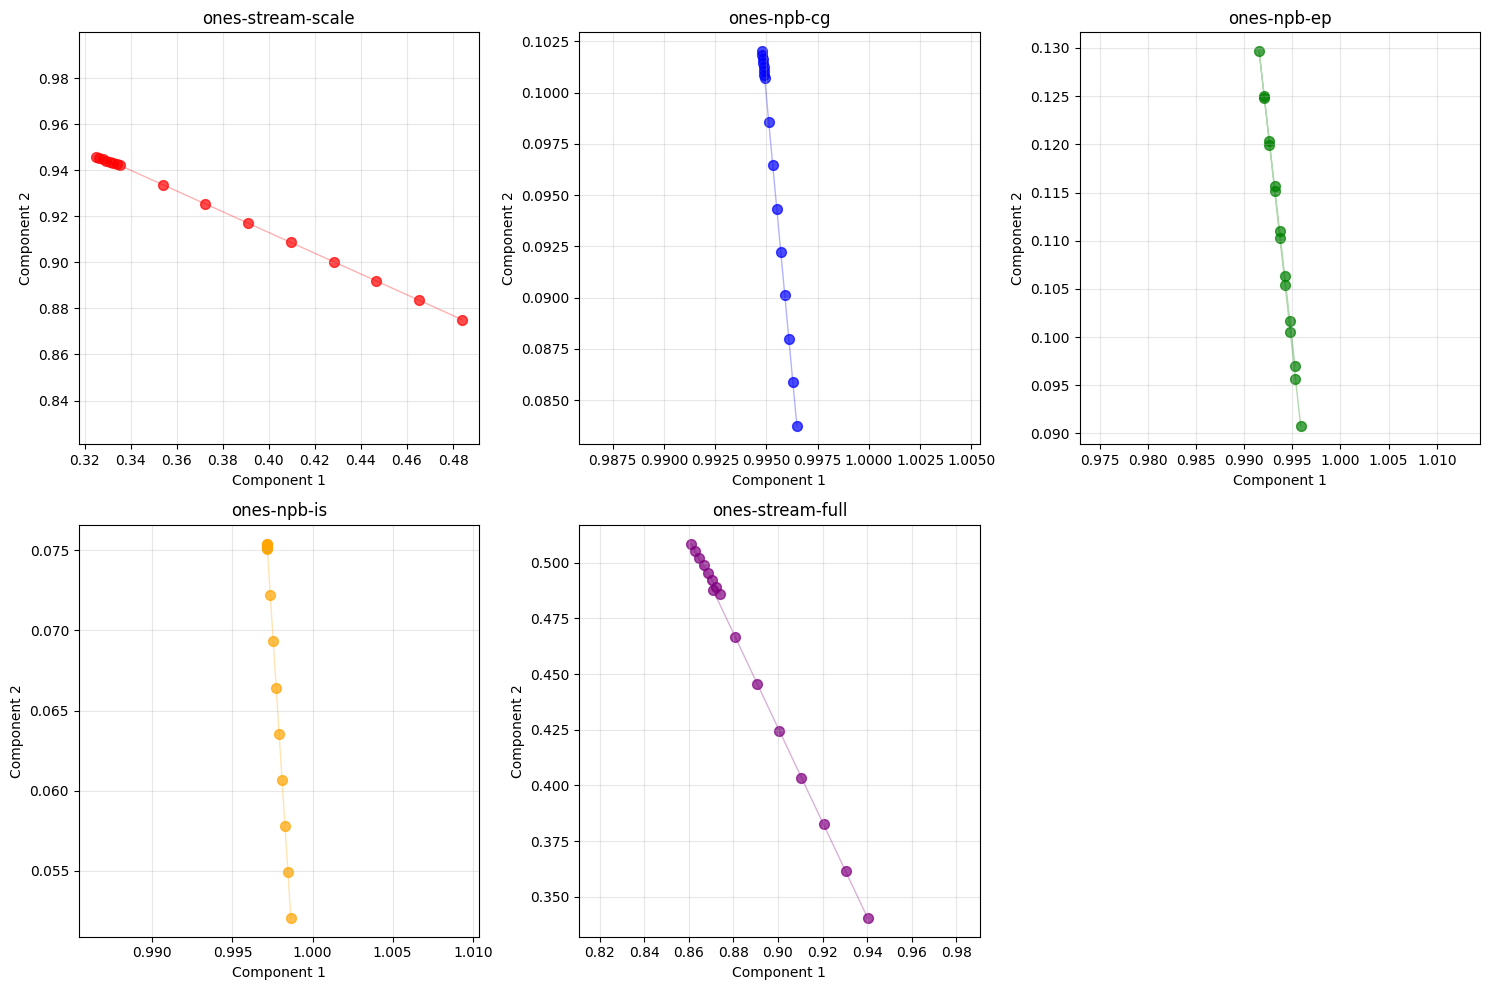

In [8]:
import matplotlib.pyplot as plt

# Create individual 2D scatter plots for each application
num_apps = len(interpolators)
cols = 3  # Number of columns
rows = (num_apps + cols - 1) // cols  # Calculate rows needed

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
if rows == 1:
    axes = axes.reshape(1, -1)

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i, (interpolator, color) in enumerate(zip(interpolators.keys(), colors)):
    row = i // cols
    col = i % cols
    ax = axes[row, col]
    
    interp = interpolators[interpolator]
    x_unit_interp = interp(w_batch_line)
    
    # Scatter plot with connected lines
    ax.scatter(x_unit_interp[:, 0], x_unit_interp[:, 1], 
               alpha=0.7, color=color, s=50)
    # Connect the points with lines to show the interpolation path
    ax.plot(x_unit_interp[:, 0], x_unit_interp[:, 1], color=color, alpha=0.3, linewidth=1)
    
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_title(f'{interpolator}')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

# Hide unused subplots
for i in range(num_apps, rows * cols):
    row = i // cols
    col = i % cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()


In [9]:
# Create interpolators WITHOUT normalization (using raw vectors)
interpolators_raw = {}
for file in next(os.walk('./'))[2]:
    if 'interp' in file:
        application_name = '_'.join(file.split('.')[0].split('_')[1:])
        x = np.loadtxt(file, delimiter=",")
        # Use raw vectors without normalization
        idx = np.round(np.linspace(0, len(w_batch_line) - 1, num=len(x))).astype(int)
        w_batch_interp = w_batch_line[idx]
        interp = RBFInterpolator(w_batch_interp, x, kernel='linear')  # Use raw x, not x_unit
        interpolators_raw[application_name] = interp

print("Created interpolators with raw (unnormalized) vectors")
print(f"Number of raw interpolators: {len(interpolators_raw)}")


Created interpolators with raw (unnormalized) vectors
Number of raw interpolators: 5


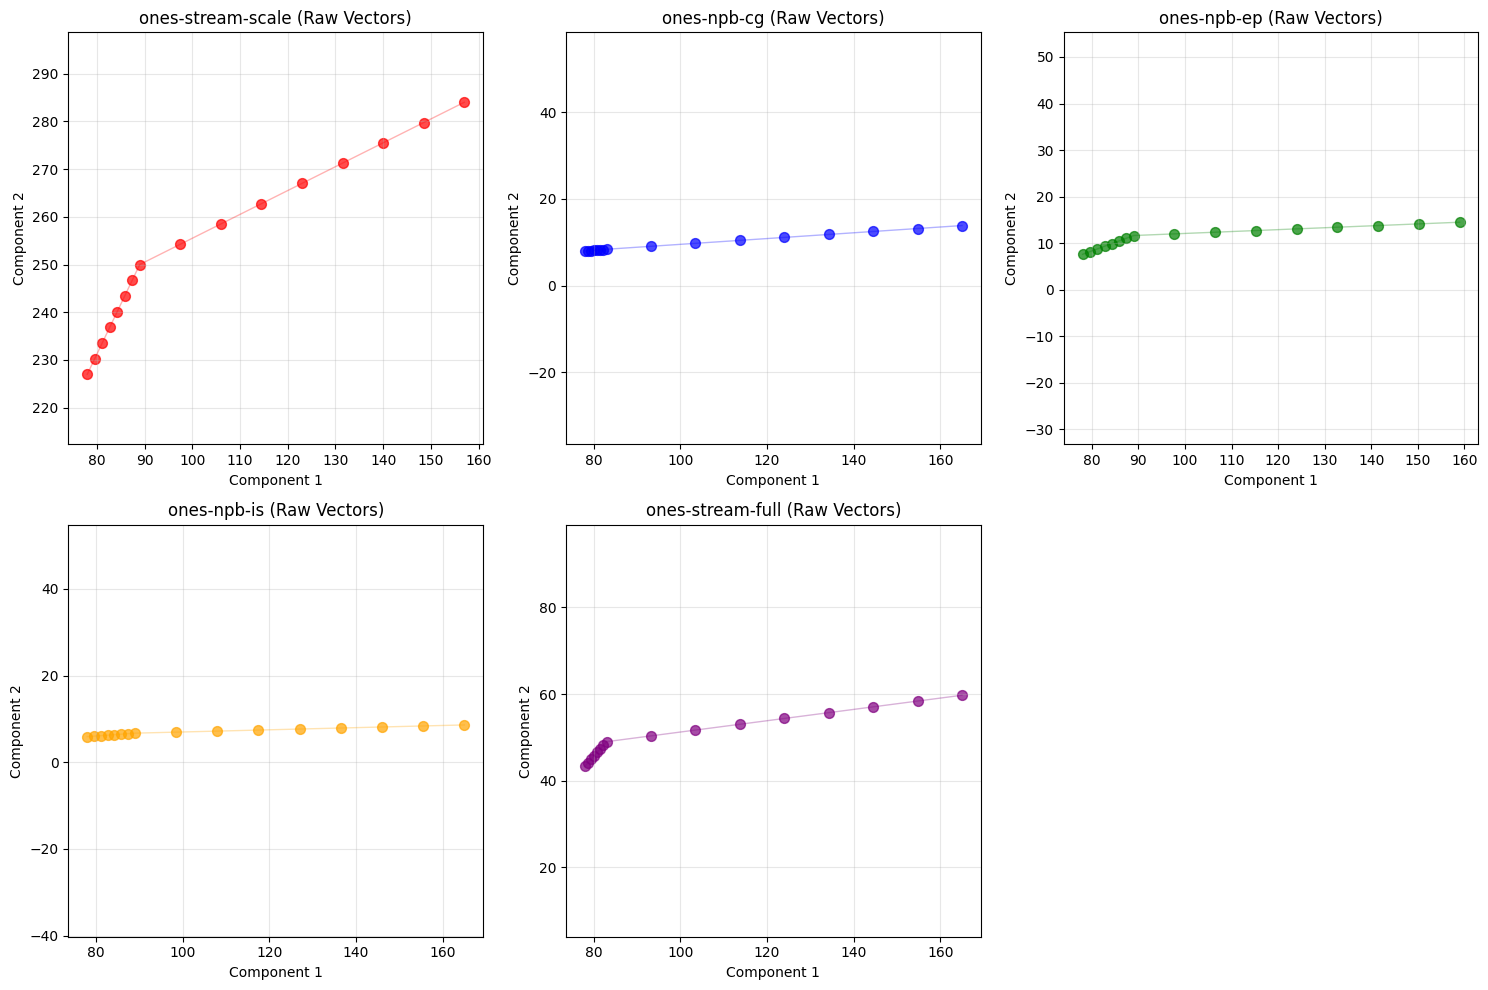

In [10]:
# Plot unnormalized interpolated vectors
import matplotlib.pyplot as plt

# Create individual 2D scatter plots for each application (RAW VECTORS)
num_apps = len(interpolators_raw)
cols = 3  # Number of columns
rows = (num_apps + cols - 1) // cols  # Calculate rows needed

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
if rows == 1:
    axes = axes.reshape(1, -1)

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i, (interpolator, color) in enumerate(zip(interpolators_raw.keys(), colors)):
    row = i // cols
    col = i % cols
    ax = axes[row, col]
    
    interp = interpolators_raw[interpolator]
    x_raw_interp = interp(w_batch_line)  # Get raw interpolated vectors
    
    # Scatter plot with connected lines
    ax.scatter(x_raw_interp[:, 0], x_raw_interp[:, 1], 
               alpha=0.7, color=color, s=50)
    # Connect the points with lines to show the interpolation path
    ax.plot(x_raw_interp[:, 0], x_raw_interp[:, 1], color=color, alpha=0.3, linewidth=1)
    
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_title(f'{interpolator} (Raw Vectors)')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

# Hide unused subplots
for i in range(num_apps, rows * cols):
    row = i // cols
    col = i % cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()
